<a href="https://colab.research.google.com/github/shindevaish/Face_Mask_Detection/blob/master/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
model = load_model("face_mask_inceptionv3.keras")

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-dataset


In [ ]:
IMG_SIZE = 299
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "/kaggle/input/face-mask-dataset/data",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    color_mode = 'rgb'
)

val_generator = train_datagen.flow_from_directory(
    "/kaggle/input/face-mask-dataset/data",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    color_mode = 'rgb'
)

Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.


In [ ]:
loss, accuracy = model.evaluate(val_generator)
print("Final Accuracy:", accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 60s 937ms/step - accuracy: 0.9927 - loss: 0.0248
Final Accuracy: 0.9927152395248413


In [ ]:
IMG_SIZE = 299

def predict_image(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_norm = img_resized / 255.0
    img_input = np.reshape(img_norm, (1, IMG_SIZE, IMG_SIZE, 3))

    pred = model.predict(img_input)[0][0]
    label = "Without Mask" if pred > 0.5 else "With Mask"

    plt.imshow(img_rgb)
    plt.title(f"Prediction: {label}")
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


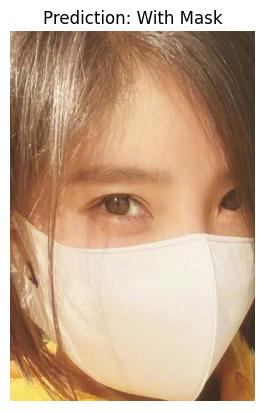

In [ ]:
predict_image("/content/with_mask_9.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


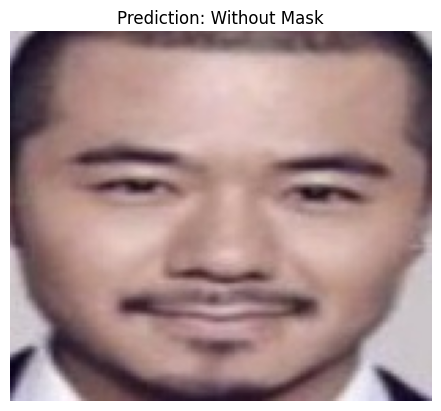

None


In [ ]:
print(predict_image("/content/without_mask_10.jpg"))